# Exploratory Data Analysis (EDA) - World Cup Predictions

This notebook performs exploratory data analysis on the training dataset to uncover patterns, statistical insights, correlations, and distributions of team performance features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('../Data/cleaned/training_data.csv')

## 1. Dataset Overview

We check the dimensions of the dataset, data types of the features, missing values, and high-level descriptive statistics.

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 29 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   tournament_name                      806 non-null    object 
 1   Home Team                            806 non-null    object 
 2   Away Team                            806 non-null    object 
 3   Final Result                         806 non-null    object 
 4   Home_Big_Chances_5                   670 non-null    float64
 5   Home_Shots_5                         703 non-null    float64
 6   Home_Shots_on_Target_5               706 non-null    float64
 7   Home_touches_in_penalty_area_5       708 non-null    float64
 8   Home_big_chances_last_5              766 non-null    float64
 9   Home_final_third_entries_last_5      778 non-null    float64
 10  Home_touches_in_penalty_area_last_5  710 non-null    float64
 11  Home_wins_last_5                

In [3]:
data.isna().sum()

tournament_name                          0
Home Team                                0
Away Team                                0
Final Result                             0
Home_Big_Chances_5                     136
Home_Shots_5                           103
Home_Shots_on_Target_5                 100
Home_touches_in_penalty_area_5          98
Home_big_chances_last_5                 40
Home_final_third_entries_last_5         28
Home_touches_in_penalty_area_last_5     96
Home_wins_last_5                       122
Home_goals_last_5                      122
Home_conceded_last_5                   122
Home_gd_last_5                         122
Away_Big_Chances_5                     149
Away_Shots_5                           103
Away_Shots_on_Target_5                 102
Away_touches_in_penalty_area_5         125
Away_big_chances_last_5                 38
Away_final_third_entries_last_5         27
Away_touches_in_penalty_area_last_5    123
Away_wins_last_5                       141
Away_goals_

In [4]:
data.describe(include='all')

,tournament_name,Home Team,Away Team,Final Result,Home_Big_Chances_5,Home_Shots_5,Home_Shots_on_Target_5,Home_touches_in_penalty_area_5,Home_big_chances_last_5,Home_final_third_entries_last_5,...,Away_big_chances_last_5,Away_final_third_entries_last_5,Away_touches_in_penalty_area_last_5,Away_wins_last_5,Away_goals_last_5,Away_conceded_last_5,Away_gd_last_5,Home_elo,Away_elo,ELO_diff
count,806,806,806,806,670.000000,703.000000,706.000000,708.000000,766.000000,778.000000,...,768.000000,779.000000,683.000000,665.000000,665.000000,665.000000,665.000000,806.000000,806.000000,806.000000
unique,5,155,153,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Qualifiers,England,Australia,H,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,343,21,16,383,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,2.331418,12.310028,4.399976,21.416714,2.409846,140.177861,...,2.259357,134.573650,50.501060,2.114286,7.566917,6.733835,0.833083,1521.567728,1515.260344,6.307384
std,NaN,NaN,NaN,NaN,1.200024,3.855263,1.709690,9.641462,1.895743,46.686895,...,1.882986,46.907942,30.739166,1.323624,4.385297,3.847212,6.579733,54.998377,54.172783,78.062493
min,NaN,NaN,NaN,NaN,0.000000,0.666667,0.200000,1.000000,0.000000,17.233647,...,0.000000,10.370370,1.000000,0.000000,0.000000,0.000000,-22.000000,1360.338805,1364.919837,-249.720656
25%,NaN,NaN,NaN,NaN,1.425000,9.750000,3.000000,14.475000,1.000000,111.755830,...,0.864198,106.829218,28.473251,1.000000,4.000000,4.000000,-4.000000,1485.820372,1481.647298,-51.979279
50%,NaN,NaN,NaN,NaN,2.250000,12.200000,4.400000,20.366667,1.995350,144.054266,...,1.848826,135.517299,43.222222,2.000000,7.000000,6.000000,1.000000,1514.437041,1509.051775,9.297725
75%,NaN,NaN,NaN,NaN,3.000000,14.800000,5.475000,26.600000,3.441468,170.339077,...,3.211881,165.824840,67.099756,3.000000,10.000000,9.000000,5.000000,1561.101323,1550.487696,62.366162


## 2. Missing Values Visualization

We visualize the proportion of missing values per feature to evaluate data quality.

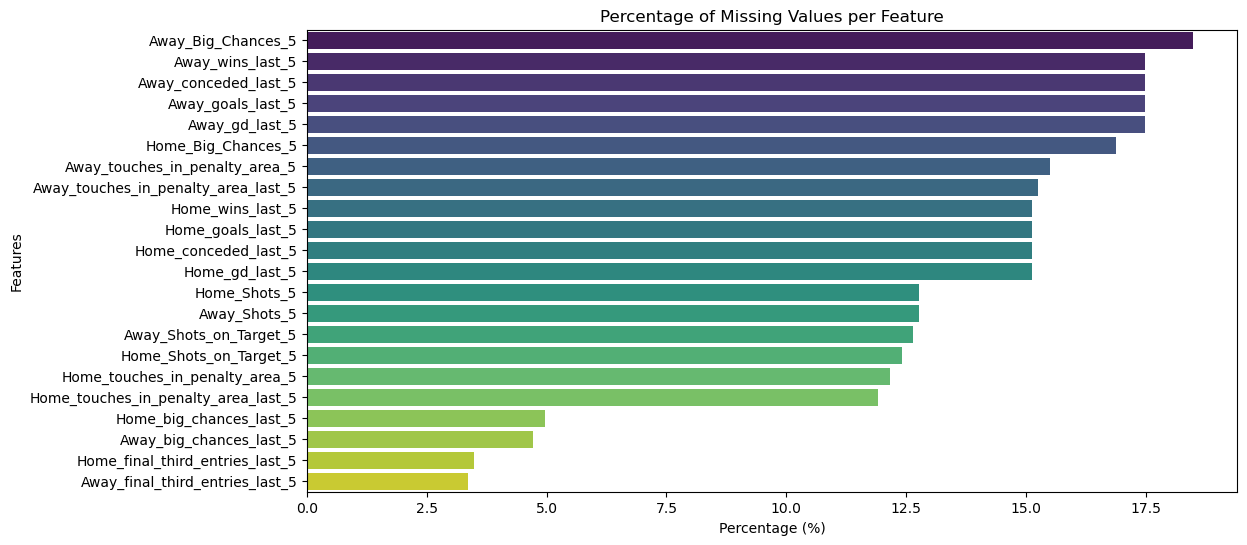

In [5]:
plt.figure(figsize=(12, 6))
missing_percentage = data.isna().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
if not missing_percentage.empty:
    sns.barplot(x=missing_percentage.values, y=missing_percentage.index, hue=missing_percentage.index, palette='viridis', legend=False)
    plt.title('Percentage of Missing Values per Feature')
    plt.xlabel('Percentage (%)')
    plt.ylabel('Features')
    plt.savefig('../Images/EDA/missing_values.png', bbox_inches='tight')
    plt.show()

## 3. Target Variable Analysis

We examine the distribution of the target variable `Final Result` (Home win 'H', Draw 'D', Away win 'A') to see if there is a class imbalance.

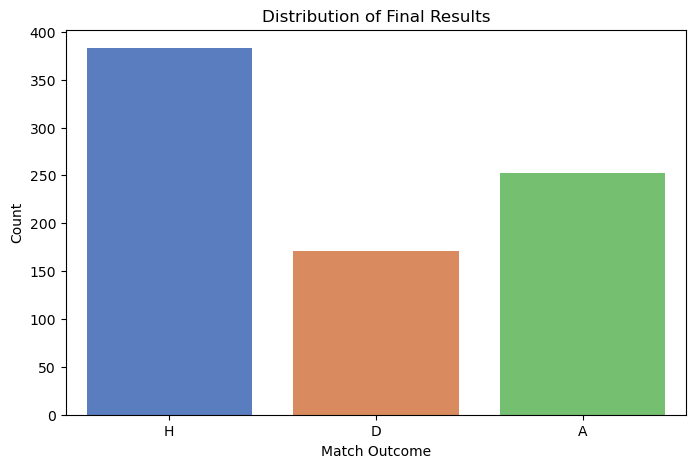

Final Result
H    0.475186
A    0.312655
D    0.212159
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Final Result', order=['H', 'D', 'A'], hue='Final Result', palette='muted', legend=False)
plt.title('Distribution of Final Results')
plt.xlabel('Match Outcome')
plt.ylabel('Count')
plt.savefig('../Images/EDA/final_results_distribution.png', bbox_inches='tight')
plt.show()

print(data['Final Result'].value_counts(normalize=True))

## 4. Match Outcomes by Tournament Type

We analyze how match outcomes vary across different tournament levels (`tournament_name`).

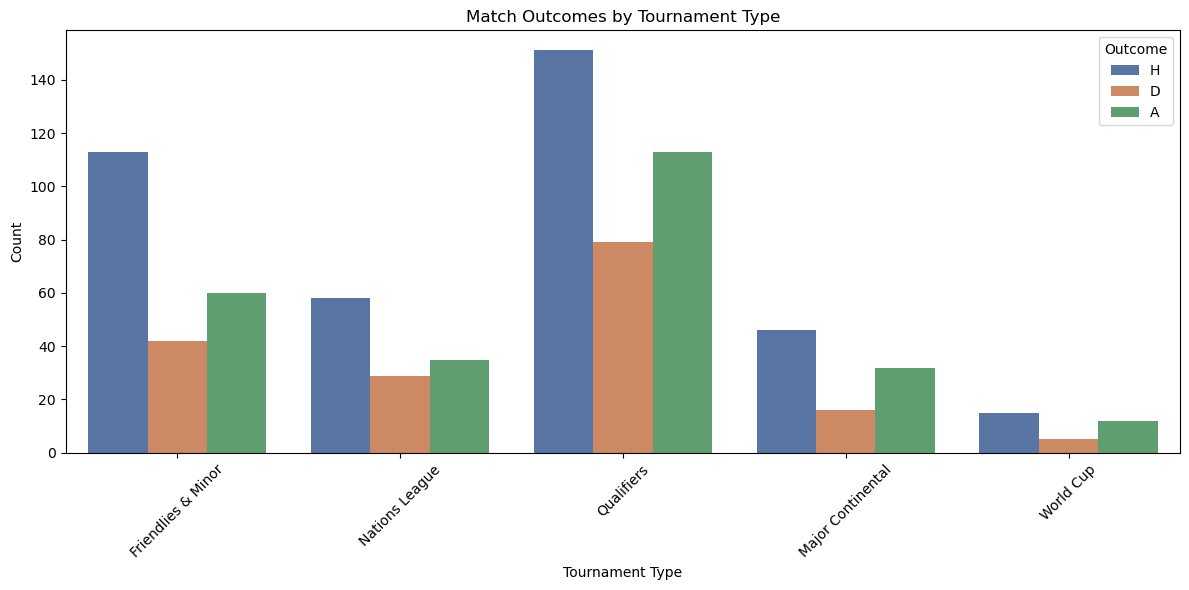

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='tournament_name', hue='Final Result', hue_order=['H', 'D', 'A'], palette='deep')
plt.title('Match Outcomes by Tournament Type')
plt.xlabel('Tournament Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Outcome')
plt.tight_layout()
plt.savefig('../Images/EDA/outcomes_by_tournament.png', bbox_inches='tight')
plt.show()

## 5. ELO Rating Analysis

ELO ratings are powerful indicators of team strength. We visualize ELO distributions and analyze how the difference in ELO (`ELO_diff`) relates to match outcomes.

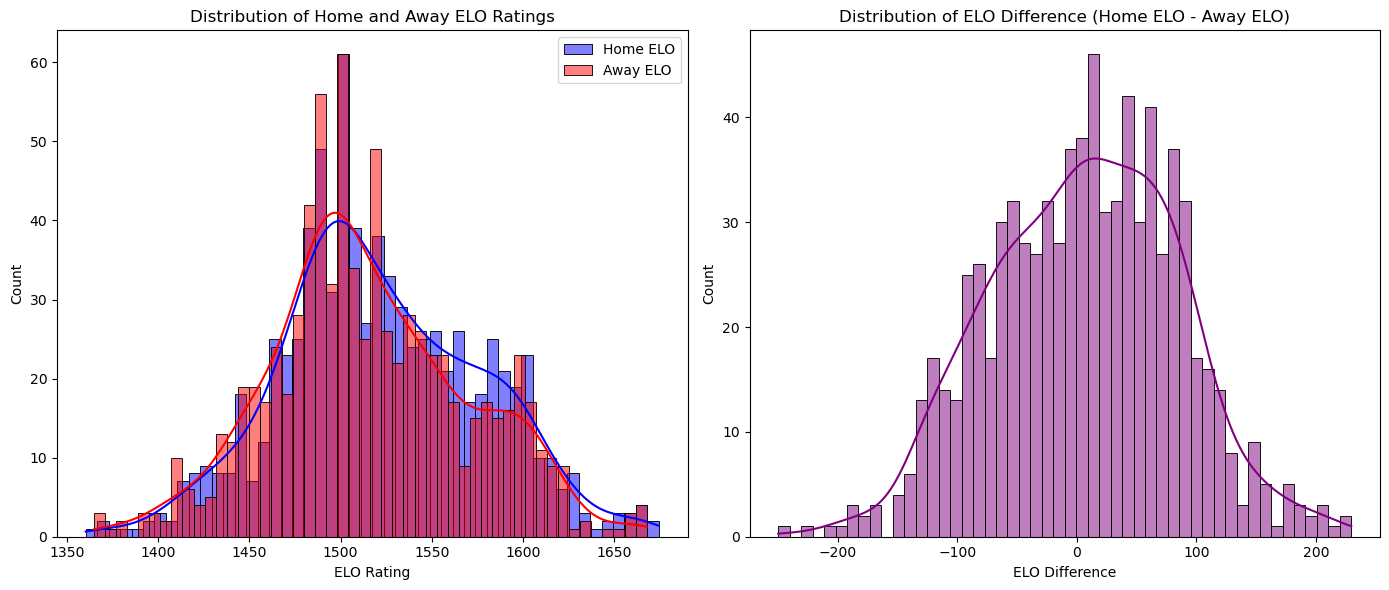

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(data['Home_elo'], kde=True, color='blue', label='Home ELO', ax=axes[0],bins=50)
sns.histplot(data['Away_elo'], kde=True, color='red', label='Away ELO', ax=axes[0],bins=50)
axes[0].set_title('Distribution of Home and Away ELO Ratings')
axes[0].set_xlabel('ELO Rating')
axes[0].legend()

sns.histplot(data['ELO_diff'], kde=True, color='purple', ax=axes[1],bins=50)
axes[1].set_title('Distribution of ELO Difference (Home ELO - Away ELO)')
axes[1].set_xlabel('ELO Difference')

plt.tight_layout()
plt.savefig('../Images/EDA/elo_distribution.png', bbox_inches='tight')
plt.show()

### ELO Difference vs Match Outcome

A positive ELO difference means the home team has a higher ELO rating than the away team. Let's see how ELO difference affects the final result.

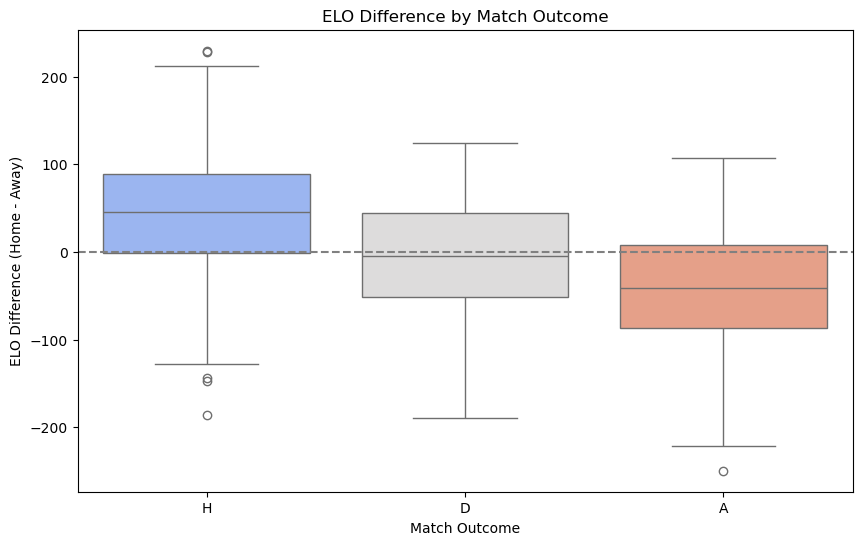

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Final Result', y='ELO_diff', order=['H', 'D', 'A'], hue='Final Result', palette='coolwarm', legend=False)
plt.title('ELO Difference by Match Outcome')
plt.xlabel('Match Outcome')
plt.ylabel('ELO Difference (Home - Away)')
plt.axhline(0, color='grey', linestyle='--')
plt.savefig('../Images/EDA/elo_diff_vs_outcome.png', bbox_inches='tight')
plt.show()

### ELO Difference Grouped and Outcome Proportions

We group the ELO difference into bins and calculate the proportion of Home wins, Draws, and Away wins in each bin.

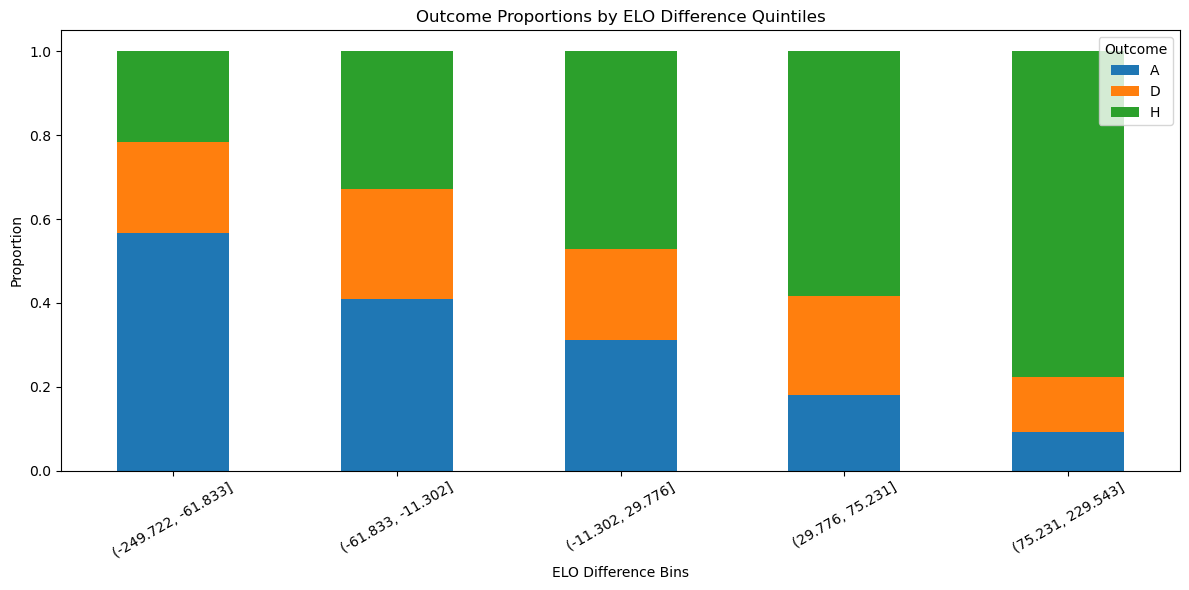

In [10]:
data['ELO_diff_bin'] = pd.qcut(data['ELO_diff'], q=5)
elo_outcome = pd.crosstab(data['ELO_diff_bin'], data['Final Result'], normalize='index')
elo_outcome.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Outcome Proportions by ELO Difference Quintiles')
plt.xlabel('ELO Difference Bins')
plt.ylabel('Proportion')
plt.legend(title='Outcome')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../Images/EDA/outcome_props_by_elo_quintiles.png', bbox_inches='tight')
plt.show()
data.drop(columns=['ELO_diff_bin'], inplace=True)

## 6. Comparison of Performance Metrics (Last 5 Matches)

We compare Home and Away team performance features, such as average shots, shots on target, goals, and goals conceded over the last 5 matches.

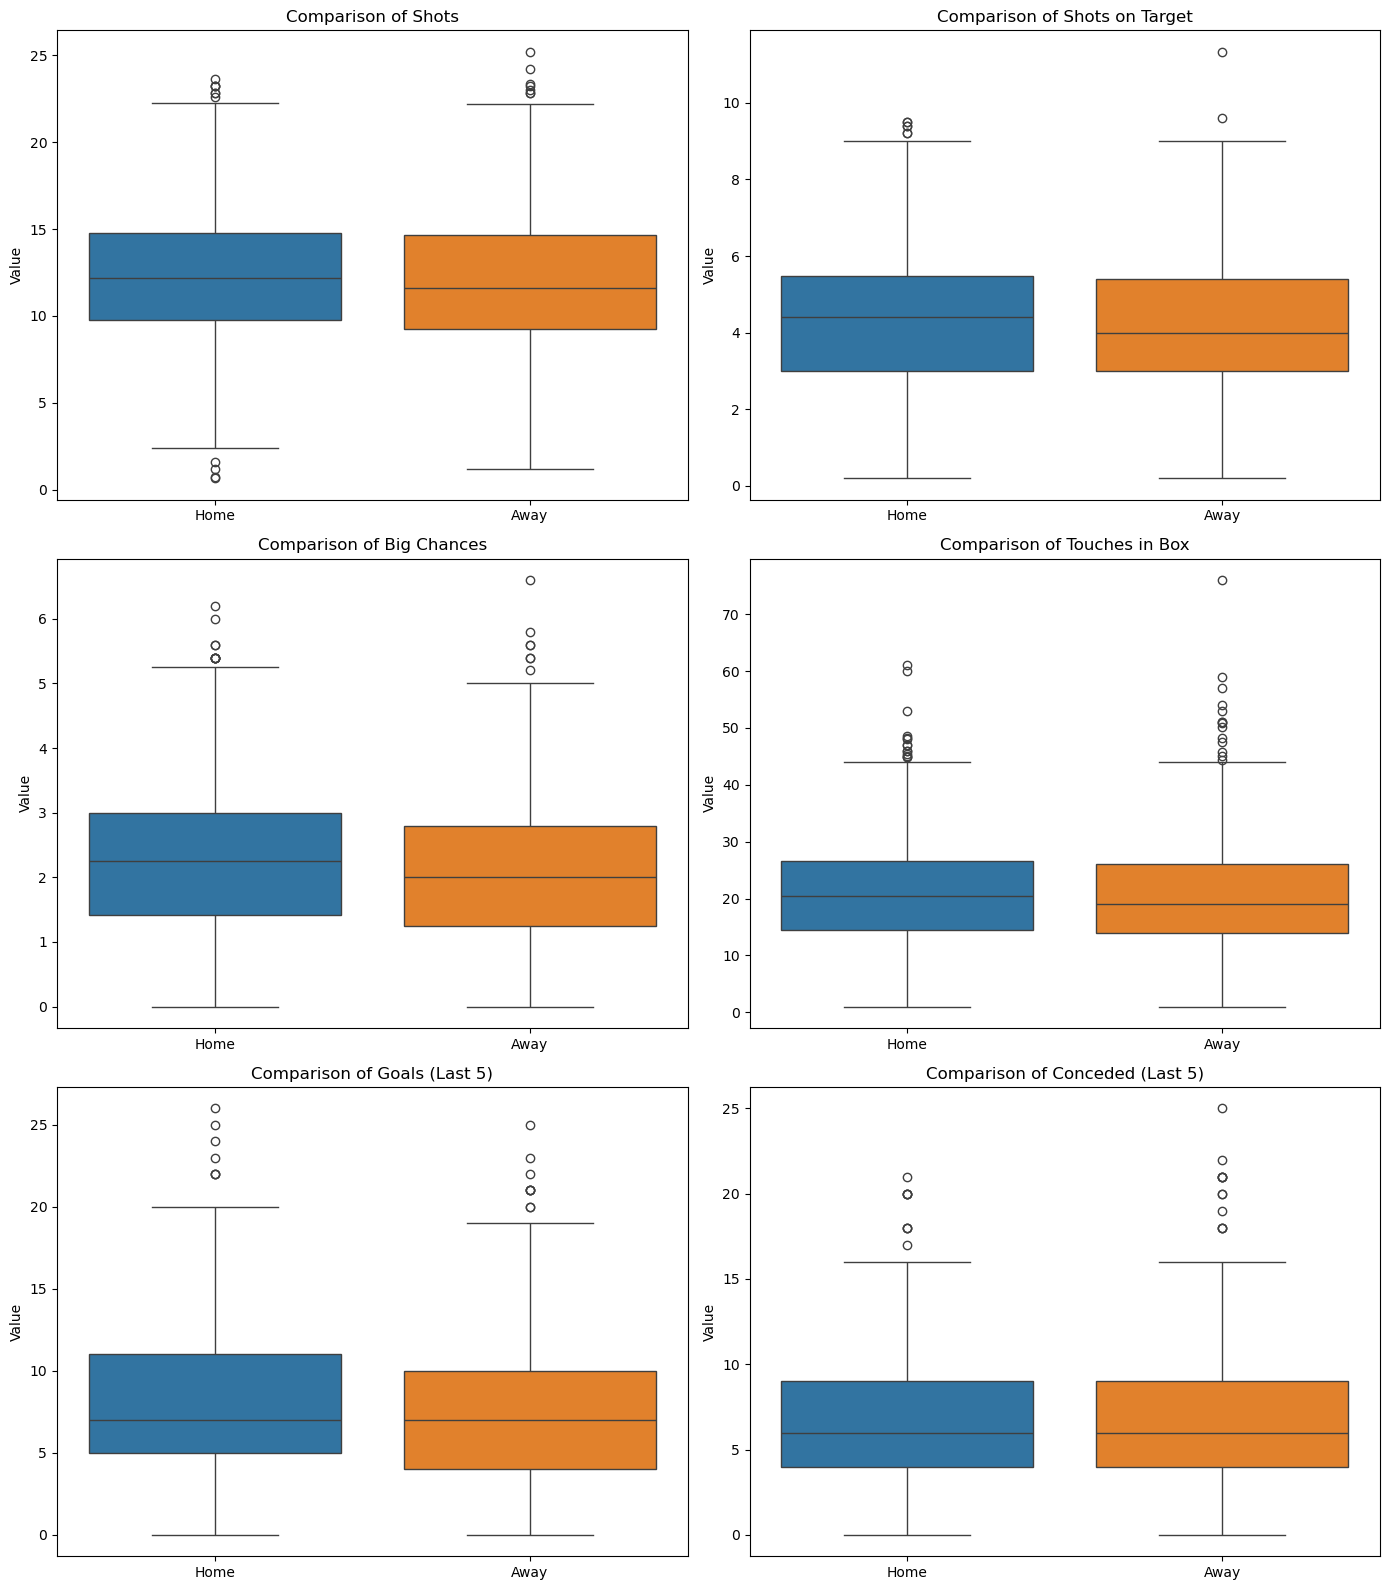

In [11]:
metrics = {
    'Shots': ('Home_Shots_5', 'Away_Shots_5'),
    'Shots on Target': ('Home_Shots_on_Target_5', 'Away_Shots_on_Target_5'),
    'Big Chances': ('Home_Big_Chances_5', 'Away_Big_Chances_5'),
    'Touches in Box': ('Home_touches_in_penalty_area_5', 'Away_touches_in_penalty_area_5'),
    'Goals (Last 5)': ('Home_goals_last_5', 'Away_goals_last_5'),
    'Conceded (Last 5)': ('Home_conceded_last_5', 'Away_conceded_last_5')
}

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for idx, (label, (home_col, away_col)) in enumerate(metrics.items()):
    data_to_plot = pd.DataFrame({
        'Home': data[home_col].dropna(),
            'Away': data[away_col].dropna()
    })
    sns.boxplot(data=data_to_plot, ax=axes[idx])
    axes[idx].set_title(f'Comparison of {label}')
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.savefig('../Images/EDA/performance_metrics_comparison.png', bbox_inches='tight')
plt.show()

## 7. Numerical Feature Correlation Analysis

We calculate and plot the correlation matrix for all numerical features to examine potential multicollinearity and identify the features most strongly correlated with match outcomes.

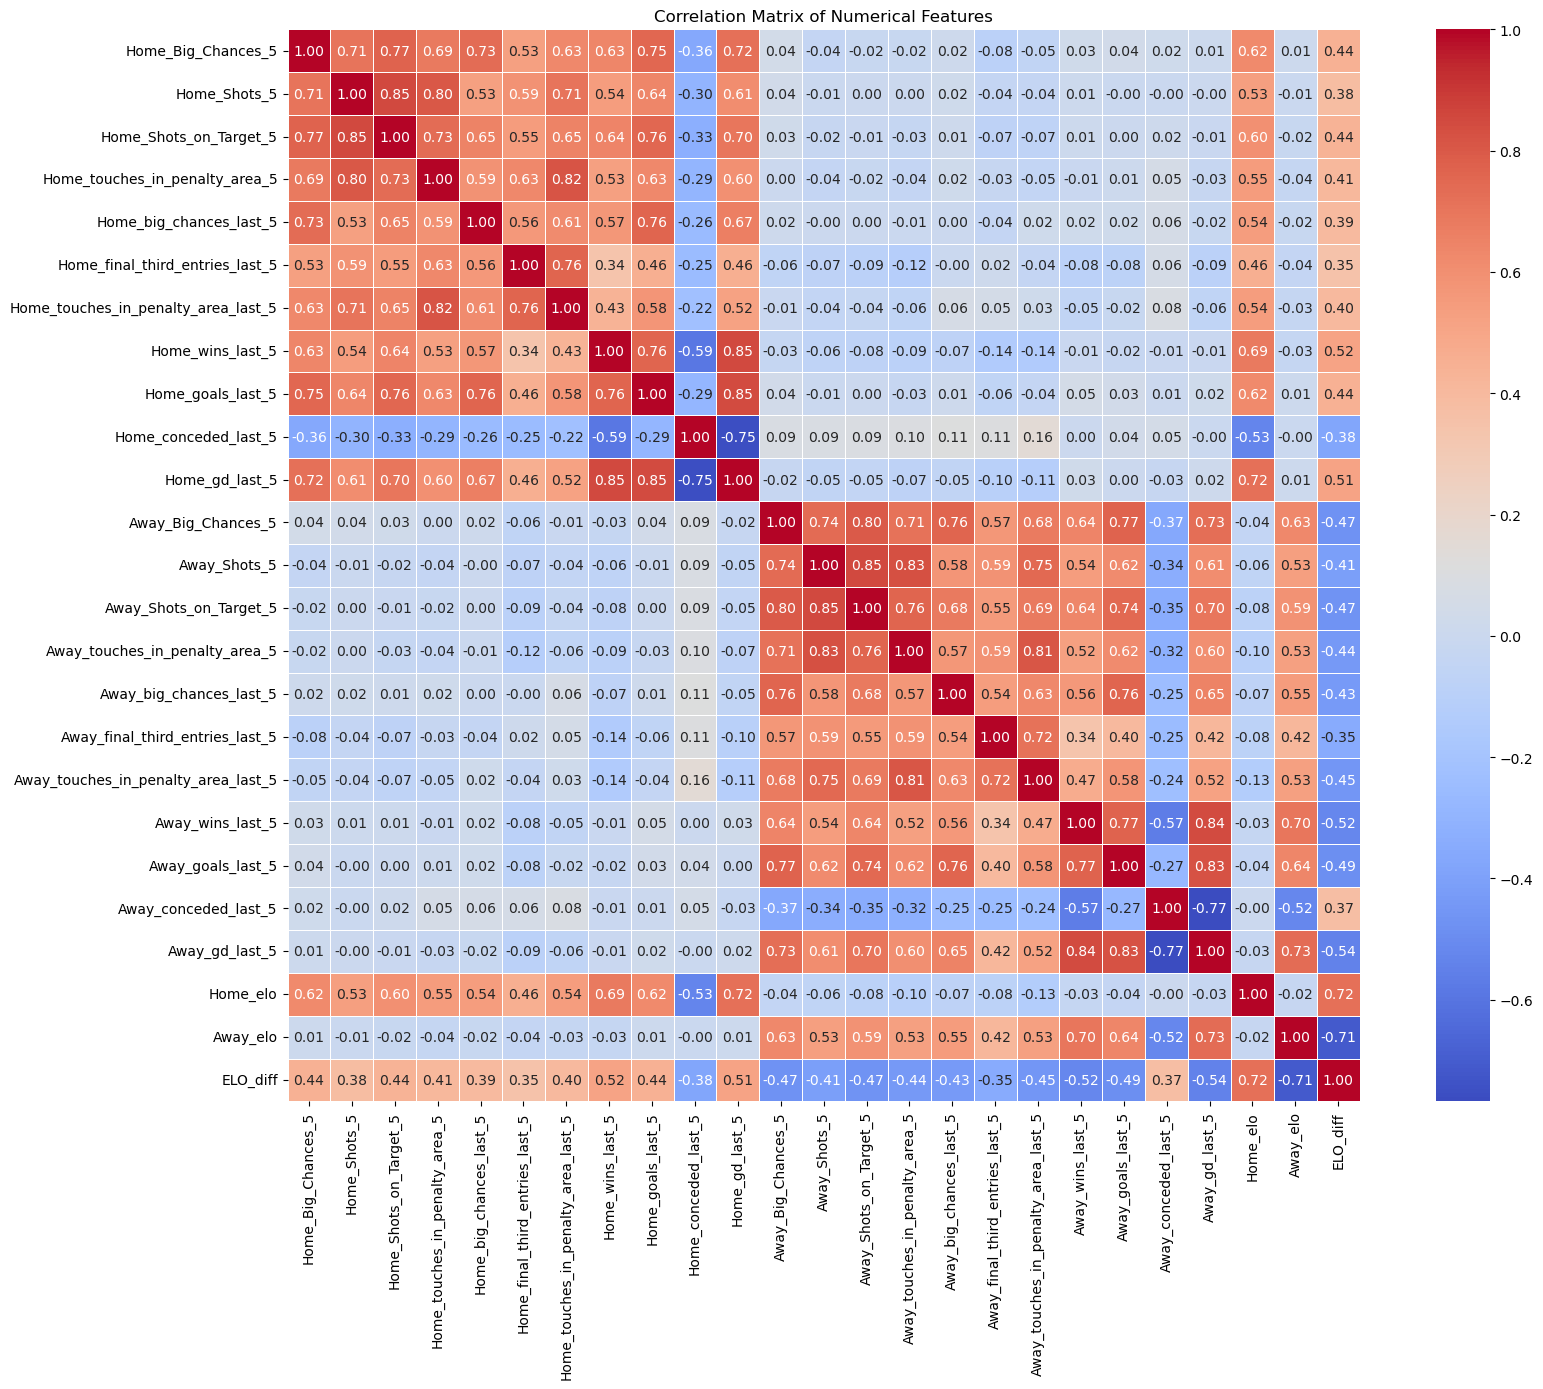

In [12]:
numerical_cols = data.select_dtypes(include=[np.number]).columns
corr_matrix = data[numerical_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('../Images/EDA/correlation_matrix.png', bbox_inches='tight')
plt.show()

## 8. Correlation of Features with Match Outcomes

To calculate correlation with the categorical `Final Result`, we encode outcomes as:
- Home Win (`Home_Win`): 1 if 'H', 0 otherwise
- Away Win (`Away_Win`): 1 if 'A', 0 otherwise
- Draw (`Draw`): 1 if 'D', 0 otherwise

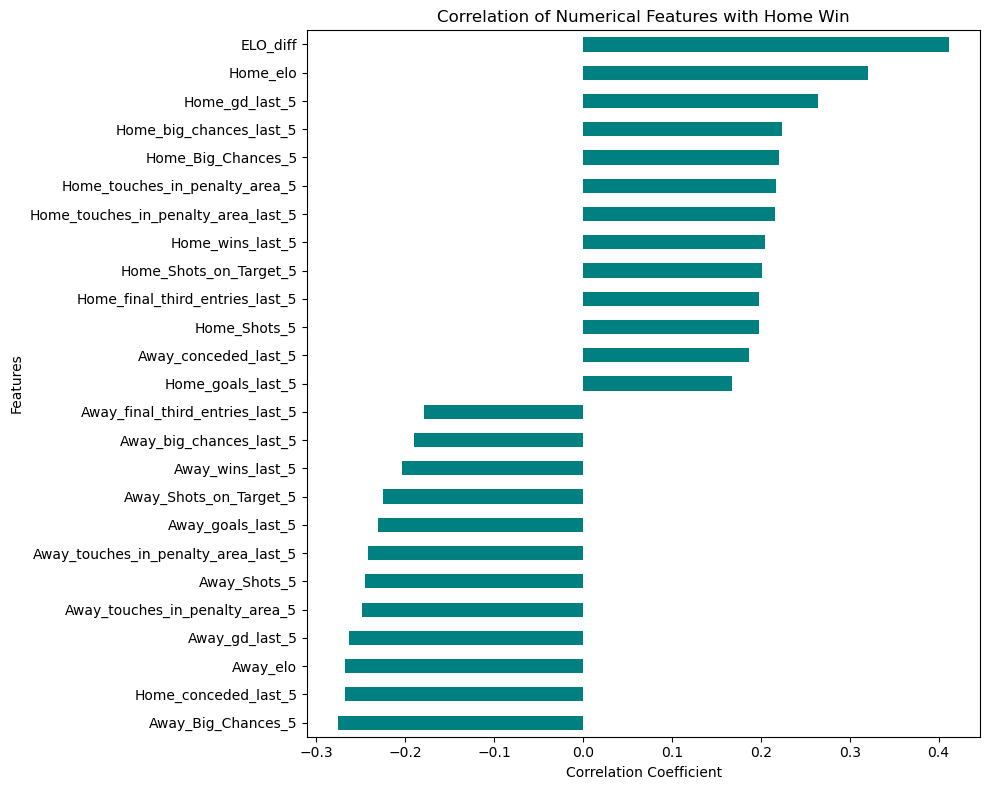

In [13]:
data_encoded = data.copy()
data_encoded['Home_Win'] = (data_encoded['Final Result'] == 'H').astype(int)
data_encoded['Away_Win'] = (data_encoded['Final Result'] == 'A').astype(int)
data_encoded['Draw'] = (data_encoded['Final Result'] == 'D').astype(int)

target_corrs = data_encoded[numerical_cols].corrwith(data_encoded['Home_Win']).sort_values()

plt.figure(figsize=(10, 8))
target_corrs.plot(kind='barh', color='teal')
plt.title('Correlation of Numerical Features with Home Win')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('../Images/EDA/correlation_with_home_win.png', bbox_inches='tight')
plt.show()